In [1]:
pip install pandas numpy seaborn matplotlib scikit-learn joblib fastapi uvicorn pydantic

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib


df = pd.read_csv('/content/data.csv')
df.head()

,subject_id,icustay_id,heart_rate,blood_pressure,oxygen_saturation,respiratory_rate,temperature,Label
0,94297,200697.0,93.0,94.0,98.0,39.0,36.0,1
1,94229,219381.0,97.0,96.0,98.0,16.0,36.5,0
2,94195,276193.0,82.0,96.0,97.0,25.0,36.3,1
3,94256,241577.0,98.0,196.0,96.0,16.0,36.5,1
4,93996,236789.0,98.0,92.0,99.0,28.0,37.2,1


In [5]:
df = df.drop(['subject_id' , 'icustay_id'], axis=1)
df.head()

,heart_rate,blood_pressure,oxygen_saturation,respiratory_rate,temperature,Label
0,93.0,94.0,98.0,39.0,36.0,1
1,97.0,96.0,98.0,16.0,36.5,0
2,82.0,96.0,97.0,25.0,36.3,1
3,98.0,196.0,96.0,16.0,36.5,1
4,98.0,92.0,99.0,28.0,37.2,1


Generating 'Before' Analysis...


Text(0.5, 1.0, 'Vitals Before Cleaning')

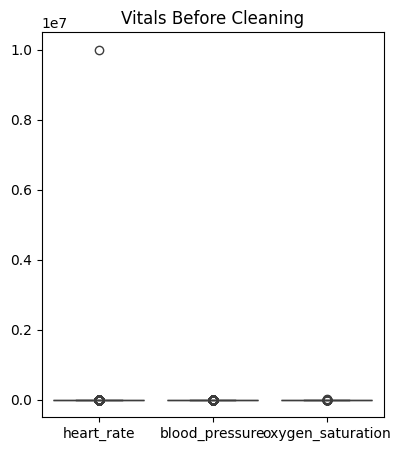

In [6]:
print("Generating 'Before' Analysis...")
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df[['heart_rate', 'blood_pressure', 'oxygen_saturation']])
plt.title("Vitals Before Cleaning")

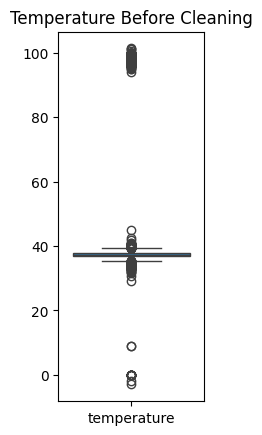

In [7]:
plt.subplot(1, 3, 2)
sns.boxplot(data=df[['temperature']])
plt.title("Temperature Before Cleaning")
plt.show()

In [8]:
def define_3_class_label(row):

    # CRITICAL Conditions
    if (row['oxygen_saturation'] < 90) or \
       (row['blood_pressure'] > 180) or \
       (row['heart_rate'] > 130) or \
       (row['temperature'] > 40):
        return "Critical"

    # WARNING Conditions
    elif (row['oxygen_saturation'] < 95) or \
         (row['blood_pressure'] > 140) or \
         (row['heart_rate'] > 100) or \
         (row['temperature'] > 38):
        return "Warning"

    # SAFE
    else:
        return "Safe"

In [12]:
def clean_data(df):
    df_c = df.copy()


    df_c['temperature'] = df_c['temperature'].apply(lambda x: (x - 32) * 5/9 if x > 50 else x)


    df_c['Label'] = df_c.apply(define_3_class_label, axis=1)


    mask = (df_c['heart_rate'].between(30, 220)) & \
           (df_c['blood_pressure'].between(40, 250)) & \
           (df_c['oxygen_saturation'].between(50, 100)) & \
           (df_c['temperature'].between(25, 45))

    df_clean = df_c[mask].copy()


    df_clean['shock_index'] = df_clean['heart_rate'] / df_clean['blood_pressure']
    df_clean['pulse_pressure_proxy'] = df_clean['blood_pressure'] - 40

    return df_clean

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23468 entries, 0 to 23467
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   heart_rate         23468 non-null  float64
 1   blood_pressure     23468 non-null  float64
 2   oxygen_saturation  23468 non-null  float64
 3   respiratory_rate   23468 non-null  float64
 4   temperature        23468 non-null  float64
 5   Label              23468 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 1.1 MB


In [11]:
df.describe()

,heart_rate,blood_pressure,oxygen_saturation,respiratory_rate,temperature,Label
count,2.346800e+04,23468.000000,23468.000000,23468.000000,23468.000000,23468.000000
mean,5.187781e+02,104.420999,97.317978,24.711991,37.903721,0.747145
std,6.527666e+04,21.025540,62.898965,11.262183,6.918300,0.434658
min,7.000000e+00,-11.000000,9.000000,2.000000,-3.000000,0.000000
25%,9.000000e+01,93.000000,96.000000,16.000000,36.800000,0.000000
50%,9.400000e+01,98.000000,97.000000,25.000000,37.200000,1.000000
75%,9.700000e+01,110.000000,98.000000,30.000000,37.800000,1.000000
max,9.999999e+06,290.000000,9560.000000,914.000000,101.300000,1.000000


In [13]:
df_final = clean_data(df)


Generating 'After' Analysis...


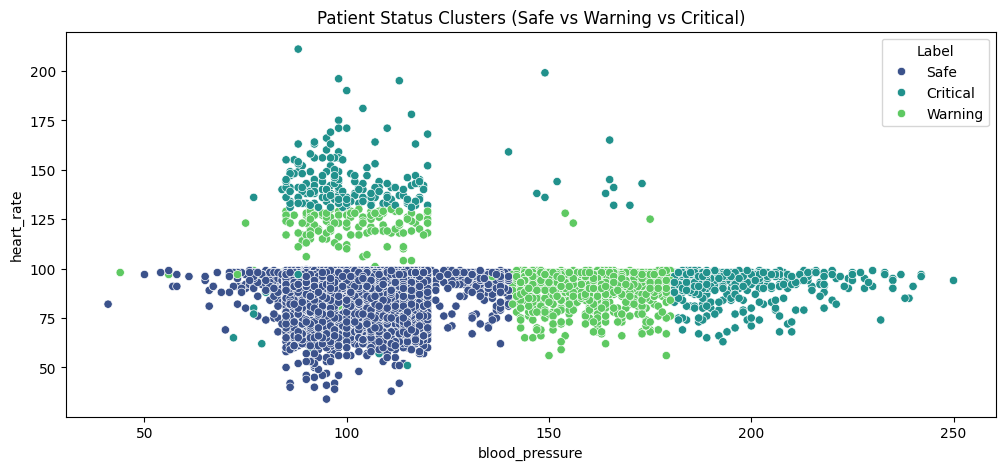

In [14]:
print("Generating 'After' Analysis...")
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_final, x='blood_pressure', y='heart_rate', hue='Label', palette='viridis')
plt.title("Patient Status Clusters (Safe vs Warning vs Critical)")
plt.show()

In [15]:
print("Class Distribution:")
print(df_final['Label'].value_counts())


Class Distribution:
Label
Safe        21013
Warning      1709
Critical      684
Name: count, dtype: int64


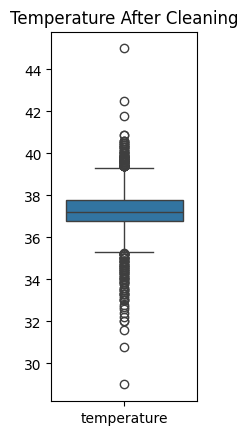

In [17]:
plt.subplot(1, 3, 2)
sns.boxplot(data=df_final[['temperature']])
plt.title("Temperature After Cleaning")
plt.show()

Generating 'After' Analysis...


Text(0.5, 1.0, 'Vitals After Cleaning')

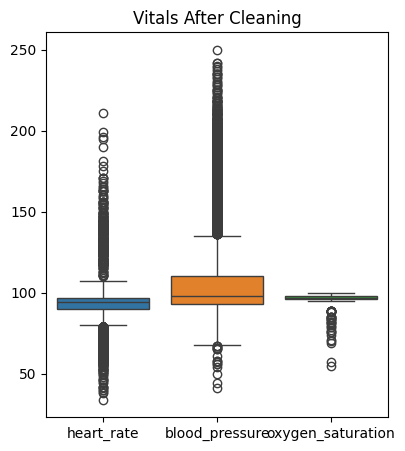

In [19]:
print("Generating 'After' Analysis...")
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_final[['heart_rate', 'blood_pressure', 'oxygen_saturation']])
plt.title("Vitals After Cleaning")

In [20]:
print(f"Data cleaned. Rows remaining: {len(df_final)}")

Data cleaned. Rows remaining: 23406


In [27]:
def add_noise(label):
    if np.random.random() < 0.10:
        return np.random.choice(["Safe", "Warning", "Critical"])
    return label

In [28]:
df_final['Label'] = df_final['Label'].apply(add_noise)

In [29]:
X = df_final[['heart_rate', 'blood_pressure', 'oxygen_saturation', 'respiratory_rate', 'temperature']]
y_raw = df_final['Label']

In [30]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


print("Model Accuracy:", model.score(X_test_scaled, y_test))


Model Accuracy: 0.9278086287911149


In [37]:
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "encoder.pkl")

['encoder.pkl']